<a href="https://www.kaggle.com/code/abreton5330/medicaid-expenditure-projection-project?scriptVersionId=320472400" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Medicaid Expenditure Projection Model

**Project goal:** Build a data-driven forecasting notebook that analyzes historical Medicaid expenditure data and projects expenditures for **2026-2035** for a selected state and for the national total.

This notebook is designed to run on **Kaggle**. It automatically searches `/kaggle/input` for the uploaded Excel files.

## Assignment checklist covered in this notebook

- Ingest and clean historical Excel files
- Perform EDA: historical trends, year-over-year growth, decomposition
- Build and evaluate multiple models: Linear Regression, Polynomial Regression, Exponential Smoothing, ARIMA
- Compare models using MAE, RMSE, and MAPE
- Select the best model for each series
- Produce 10-year forecasts for 2026-2035
- Include 95% confidence intervals
- Visualize historical and forecasted expenditures
- Export forecast tables, model comparison, charts, HTML report, PDF report, and README

## 1. Setup

Change `STATE` below if your instructor wants a different state. The rest of the notebook will run automatically.

In [1]:
STATE = "NEW YORK"   # Change this if needed, for example: "NEW JERSEY", "TEXAS", "CALIFORNIA"
FORECAST_START_YEAR = 2026
FORECAST_END_YEAR = 2035
TEST_SIZE = 3

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import os
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

from matplotlib.backends.backend_pdf import PdfPages

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (11, 6)

## 2. Locate and load the Excel files

Kaggle stores uploaded datasets inside `/kaggle/input`. This cell searches all folders inside that location and finds files named like `FY_2013_MFCU_Statistical_Chart.xlsx`.

In [3]:
search_root = Path("/kaggle/input") if Path("/kaggle/input").exists() else Path(".")
files = sorted(search_root.rglob("FY_*_MFCU_Statistical_Chart.xlsx"))

print(f"Search root: {search_root}")
print(f"Excel files found: {len(files)}")
for file in files:
    print(file)

if len(files) == 0:
    raise FileNotFoundError(
        "No Excel files were found. In Kaggle, use Add Data to attach the dataset containing the FY Excel files."
    )

Search root: /kaggle/input
Excel files found: 13
/kaggle/input/datasets/abreton5330/medicaid-expenditure-projection-model/Medicaid Expenditure Projection Model Project/FY_2013_MFCU_Statistical_Chart.xlsx
/kaggle/input/datasets/abreton5330/medicaid-expenditure-projection-model/Medicaid Expenditure Projection Model Project/FY_2014_MFCU_Statistical_Chart.xlsx
/kaggle/input/datasets/abreton5330/medicaid-expenditure-projection-model/Medicaid Expenditure Projection Model Project/FY_2015_MFCU_Statistical_Chart.xlsx
/kaggle/input/datasets/abreton5330/medicaid-expenditure-projection-model/Medicaid Expenditure Projection Model Project/FY_2016_MFCU_Statistical_Chart.xlsx
/kaggle/input/datasets/abreton5330/medicaid-expenditure-projection-model/Medicaid Expenditure Projection Model Project/FY_2017_MFCU_Statistical_Chart.xlsx
/kaggle/input/datasets/abreton5330/medicaid-expenditure-projection-model/Medicaid Expenditure Projection Model Project/FY_2018_MFCU_Statistical_Chart.xlsx
/kaggle/input/dataset

## 3. Data cleaning functions

The files do not use perfectly identical column names every year. For example, some years use `State`, others use `State1`, and Medicaid expenditure columns may have footnote numbers. These helper functions make the cleaning process reliable.

In [4]:
def extract_fiscal_year(file_path):
    """Extract fiscal year from a filename like FY_2025_MFCU_Statistical_Chart.xlsx."""
    match = re.search(r"FY_(\d{4})", file_path.name)
    if not match:
        raise ValueError(f"Could not extract fiscal year from {file_path.name}")
    return int(match.group(1))


def find_state_column(columns):
    """Find the state column, allowing names like State or State1."""
    for col in columns:
        cleaned = re.sub(r"\d+$", "", str(col)).strip().lower()
        if cleaned == "state":
            return col
    raise ValueError(f"Could not find a State column. Columns found: {list(columns)}")


def find_expenditure_column(columns):
    """Find the total Medicaid expenditure column, allowing footnote numbers."""
    candidates = [col for col in columns if "total medicaid expenditures" in str(col).lower()]
    if not candidates:
        raise ValueError(f"Could not find Medicaid expenditure column. Columns found: {list(columns)}")
    return candidates[0]


def clean_state_name(value):
    """Standardize state names and national total row names."""
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    value = value.replace(":", "")
    value = re.sub(r"\s+", " ", value)
    upper = value.upper()
    if upper in ["TOTAL", "GRAND TOTAL", "TOTALS"] or upper.startswith("TOTAL") or upper.startswith("GRAND TOTAL"):
        return "TOTAL"
    return upper


def to_number(series):
    """Convert currency-like values to numeric."""
    return pd.to_numeric(
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

In [5]:
all_data = []
load_log = []

for file in files:
    year = extract_fiscal_year(file)
    raw = pd.read_excel(file, header=1)
    raw.columns = raw.columns.astype(str).str.strip()
    
    state_col = find_state_column(raw.columns)
    expenditure_col = find_expenditure_column(raw.columns)
    
    temp = pd.DataFrame({
        "Fiscal Year": year,
        "State_raw": raw[state_col],
        "State": raw[state_col].apply(clean_state_name),
        "Expenditures": to_number(raw[expenditure_col]),
        "Source File": file.name
    })
    
    # Keep state rows and national total rows that have actual expenditure values.
    temp = temp.dropna(subset=["State", "Expenditures"])
    
    all_data.append(temp)
    load_log.append({
        "Fiscal Year": year,
        "Rows Loaded": len(temp),
        "State Column": state_col,
        "Expenditure Column": expenditure_col,
        "File": file.name
    })

medicaid = pd.concat(all_data, ignore_index=True)
load_log = pd.DataFrame(load_log).sort_values("Fiscal Year")

print("Combined data shape:", medicaid.shape)
display(load_log)
display(medicaid.head())

Combined data shape: (683, 5)


,Fiscal Year,Rows Loaded,State Column,Expenditure Column,File
0,2013,51,State,Total Medicaid Expenditures,FY_2013_MFCU_Statistical_Chart.xlsx
1,2014,51,State,Total Medicaid Expenditures,FY_2014_MFCU_Statistical_Chart.xlsx
2,2015,51,State,Total Medicaid Expenditures3,FY_2015_MFCU_Statistical_Chart.xlsx
3,2016,51,State,Total Medicaid Expenditures3,FY_2016_MFCU_Statistical_Chart.xlsx
4,2017,51,State,Total Medicaid Expenditures3,FY_2017_MFCU_Statistical_Chart.xlsx
5,2018,51,State,Total Medicaid Expenditures3,FY_2018_MFCU_Statistical_Chart.xlsx
6,2019,53,State1,Total Medicaid Expenditures4,FY_2019_MFCU_Statistical_Chart.xlsx
7,2020,54,State,Total Medicaid Expenditures3,FY_2020_MFCU_Statistical_Chart.xlsx
8,2021,54,State,Total Medicaid Expenditures3,FY_2021_MFCU_Statistical_Chart.xlsx
9,2022,54,State,Total Medicaid Expenditures3,FY_2022_MFCU_Statistical_Chart.xlsx


,Fiscal Year,State_raw,State,Expenditures,Source File
0,2013,Alabama,ALABAMA,"5,216,155,508.00",FY_2013_MFCU_Statistical_Chart.xlsx
1,2013,Alaska,ALASKA,"1,446,189,444.00",FY_2013_MFCU_Statistical_Chart.xlsx
2,2013,Arizona,ARIZONA,"8,669,976,278.00",FY_2013_MFCU_Statistical_Chart.xlsx
3,2013,Arkansas,ARKANSAS,"4,428,390,909.00",FY_2013_MFCU_Statistical_Chart.xlsx
4,2013,California,CALIFORNIA,"66,056,757,855.00",FY_2013_MFCU_Statistical_Chart.xlsx


## 4. Validate the cleaned data

This step checks whether the selected state and the national total are present across the expected fiscal years.

In [6]:
available_states = sorted(medicaid["State"].dropna().unique())
print(f"Number of unique State labels: {len(available_states)}")
print("Selected state:", STATE.upper())

if STATE.upper() not in available_states:
    print("Selected state was not found. Here are matching or nearby state labels:")
    matches = [s for s in available_states if STATE.split()[0].upper() in s]
    print(matches[:20])
    raise ValueError("Please update STATE at the top of the notebook to match one of the available state names.")

state_df = medicaid[medicaid["State"] == STATE.upper()].copy()
national_df = medicaid[medicaid["State"] == "TOTAL"].copy()

state_df = state_df.sort_values("Fiscal Year")
national_df = national_df.sort_values("Fiscal Year")

print(f"{STATE.upper()} rows:", state_df.shape[0])
print("National TOTAL rows:", national_df.shape[0])

display(state_df[["Fiscal Year", "State", "Expenditures"]])
display(national_df[["Fiscal Year", "State", "Expenditures"]])

Number of unique State labels: 54
Selected state: NEW YORK
NEW YORK rows: 13
National TOTAL rows: 13


,Fiscal Year,State,Expenditures
32,2013,NEW YORK,"54,192,911,238.00"
83,2014,NEW YORK,"53,915,930,694.00"
134,2015,NEW YORK,"59,681,117,761.00"
185,2016,NEW YORK,"62,909,519,309.00"
236,2017,NEW YORK,"78,563,137,293.00"
287,2018,NEW YORK,"75,262,657,182.00"
338,2019,NEW YORK,"60,209,122,828.00"
391,2020,NEW YORK,"72,816,196,684.00"
445,2021,NEW YORK,"73,267,974,087.00"
499,2022,NEW YORK,"82,564,771,704.00"


,Fiscal Year,State,Expenditures
50,2013,TOTAL,"453,082,711,064.00"
101,2014,TOTAL,"488,240,409,971.00"
152,2015,TOTAL,"548,190,828,914.00"
203,2016,TOTAL,"571,229,555,606.00"
254,2017,TOTAL,"596,434,360,108.00"
305,2018,TOTAL,"611,976,826,895.00"
358,2019,TOTAL,"614,908,690,223.00"
412,2020,TOTAL,"678,892,781,237.00"
466,2021,TOTAL,"740,285,561,048.00"
520,2022,TOTAL,"823,865,414,079.00"


## 5. Exploratory Data Analysis

This section visualizes historical Medicaid expenditures and year-over-year growth for the selected state and the national total.

In [7]:
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
CHART_DIR = OUTPUT_DIR / "charts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /kaggle/working


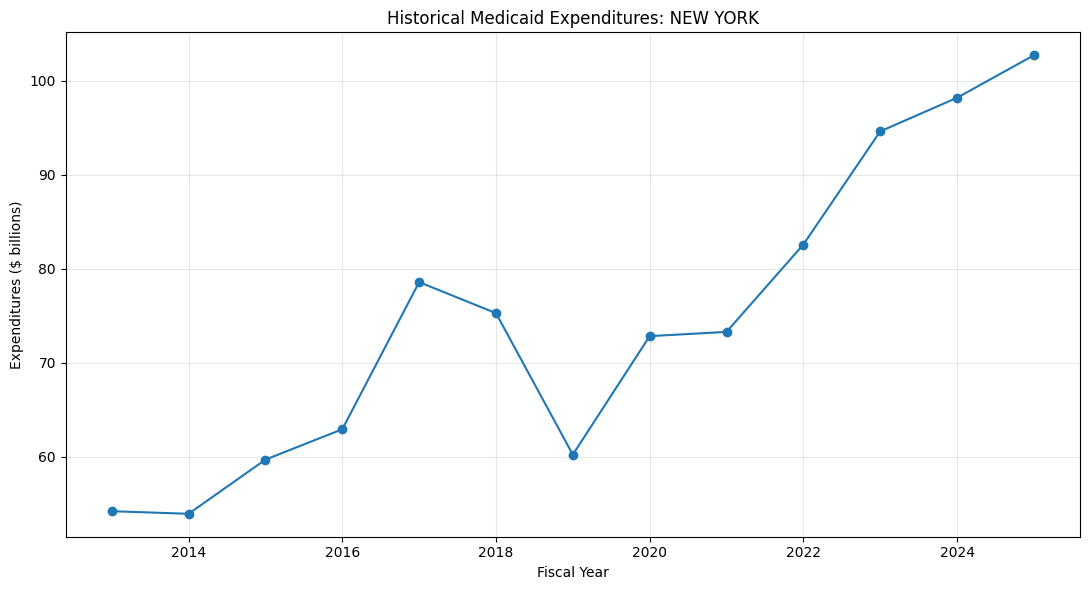

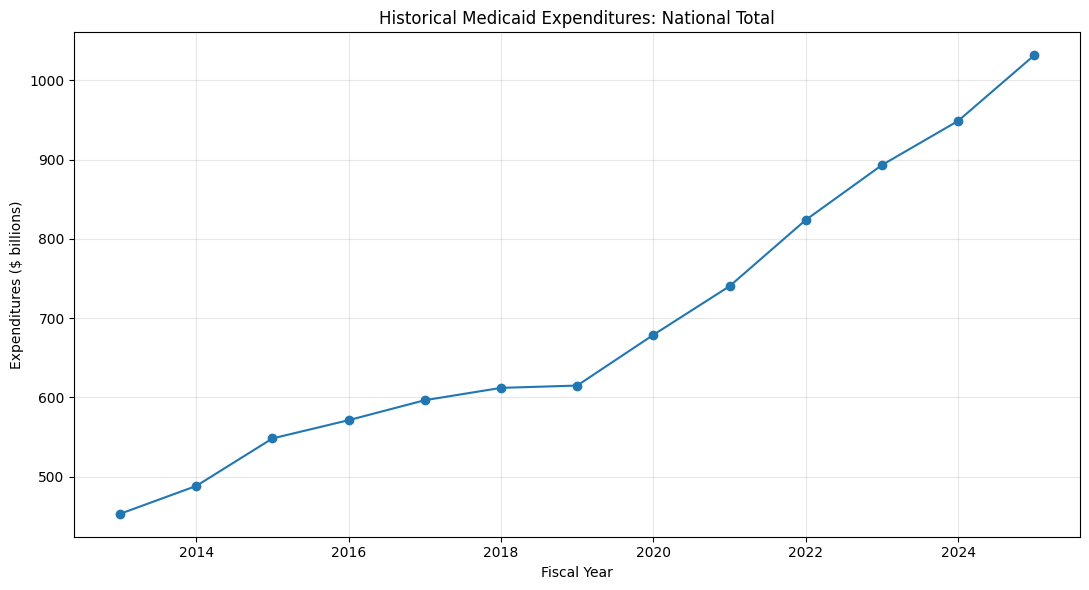

In [8]:
def dollars_billions(x):
    return x / 1_000_000_000


def plot_history(df, title, filename):
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(df["Fiscal Year"], dollars_billions(df["Expenditures"]), marker="o")
    ax.set_title(title)
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel("Expenditures ($ billions)")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    path = CHART_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path

state_history_chart = plot_history(state_df, f"Historical Medicaid Expenditures: {STATE.upper()}", "state_historical_expenditures.png")
national_history_chart = plot_history(national_df, "Historical Medicaid Expenditures: National Total", "national_historical_expenditures.png")

In [9]:
def add_yoy_growth(df):
    out = df.copy().sort_values("Fiscal Year")
    out["YoY Growth %"] = out["Expenditures"].pct_change() * 100
    return out

state_eda = add_yoy_growth(state_df)
national_eda = add_yoy_growth(national_df)

display(state_eda[["Fiscal Year", "State", "Expenditures", "YoY Growth %"]])
display(national_eda[["Fiscal Year", "State", "Expenditures", "YoY Growth %"]])

,Fiscal Year,State,Expenditures,YoY Growth %
32,2013,NEW YORK,"54,192,911,238.00",NaN
83,2014,NEW YORK,"53,915,930,694.00",-0.51
134,2015,NEW YORK,"59,681,117,761.00",10.69
185,2016,NEW YORK,"62,909,519,309.00",5.41
236,2017,NEW YORK,"78,563,137,293.00",24.88
287,2018,NEW YORK,"75,262,657,182.00",-4.20
338,2019,NEW YORK,"60,209,122,828.00",-20.00
391,2020,NEW YORK,"72,816,196,684.00",20.94
445,2021,NEW YORK,"73,267,974,087.00",0.62
499,2022,NEW YORK,"82,564,771,704.00",12.69


,Fiscal Year,State,Expenditures,YoY Growth %
50,2013,TOTAL,"453,082,711,064.00",NaN
101,2014,TOTAL,"488,240,409,971.00",7.76
152,2015,TOTAL,"548,190,828,914.00",12.28
203,2016,TOTAL,"571,229,555,606.00",4.20
254,2017,TOTAL,"596,434,360,108.00",4.41
305,2018,TOTAL,"611,976,826,895.00",2.61
358,2019,TOTAL,"614,908,690,223.00",0.48
412,2020,TOTAL,"678,892,781,237.00",10.41
466,2021,TOTAL,"740,285,561,048.00",9.04
520,2022,TOTAL,"823,865,414,079.00",11.29


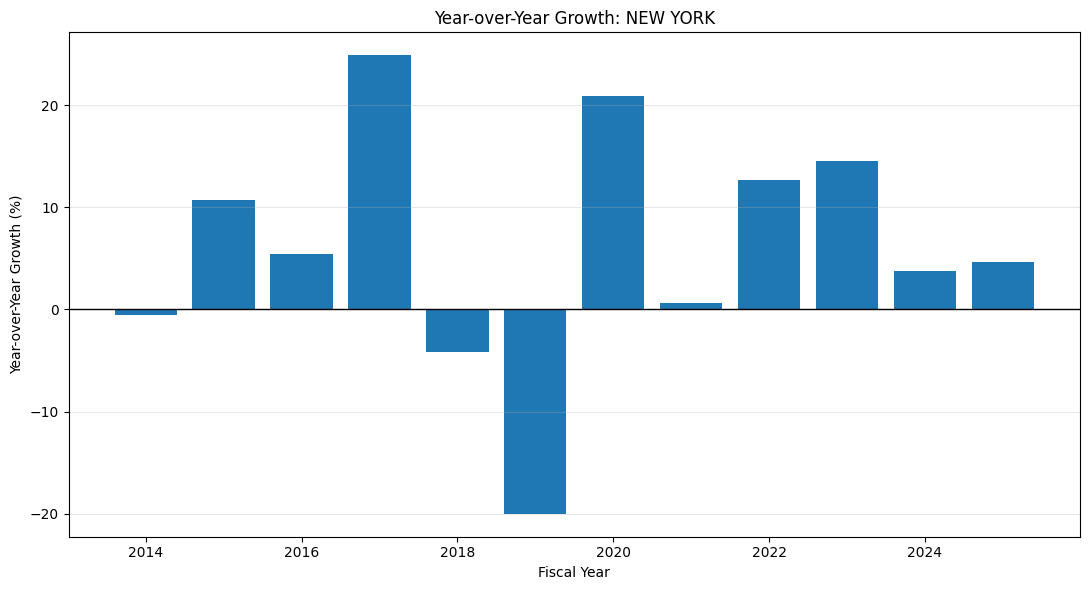

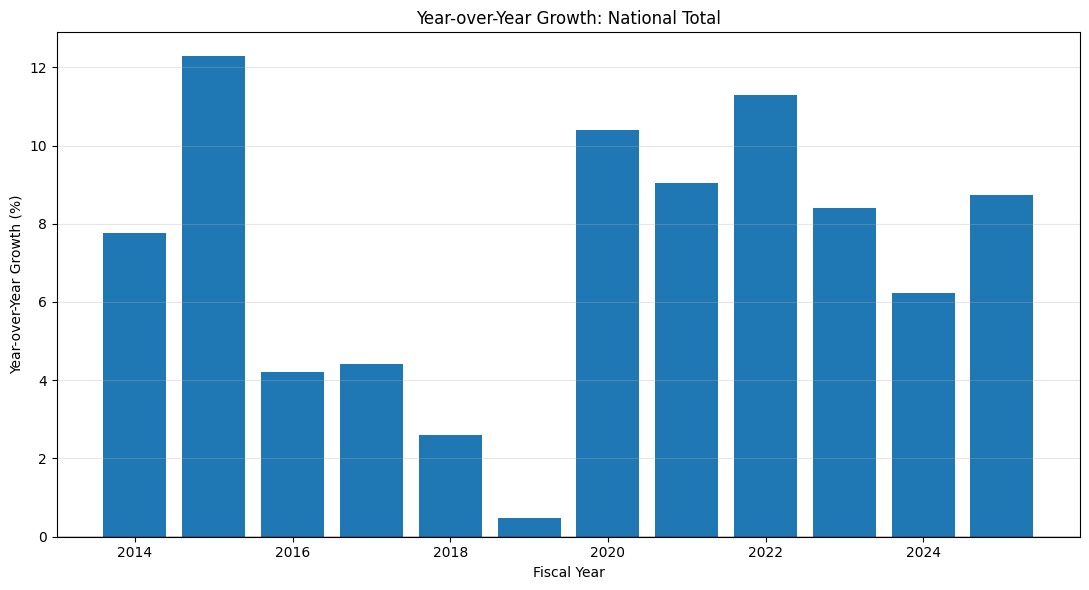

In [10]:
def plot_growth(df, title, filename):
    fig, ax = plt.subplots(figsize=(11, 6))
    growth_df = df.dropna(subset=["YoY Growth %"])
    ax.bar(growth_df["Fiscal Year"], growth_df["YoY Growth %"])
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel("Year-over-Year Growth (%)")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    path = CHART_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path

state_growth_chart = plot_growth(state_eda, f"Year-over-Year Growth: {STATE.upper()}", "state_yoy_growth.png")
national_growth_chart = plot_growth(national_eda, "Year-over-Year Growth: National Total", "national_yoy_growth.png")

## 6. Time-series decomposition

The dataset is annual, so seasonality is limited. The decomposition below is included as a diagnostic view of trend, seasonal-like movement, and residuals. A short period of 3 is used because there are only 13 annual observations.

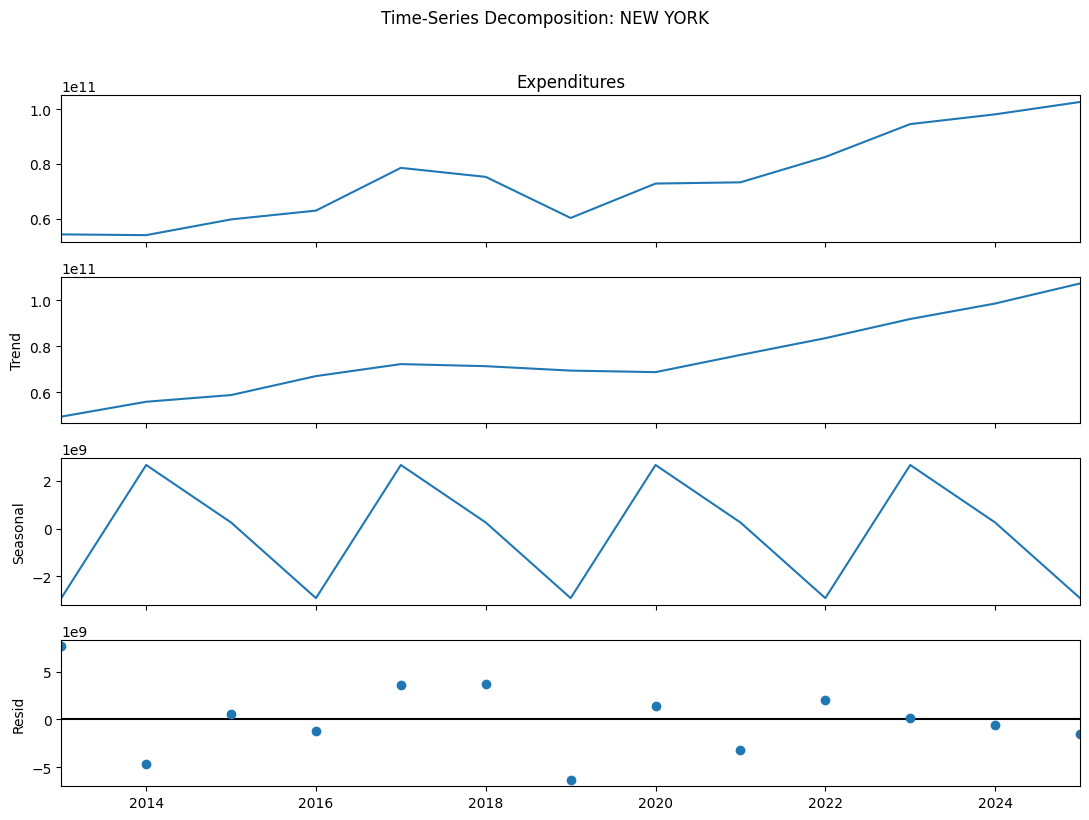

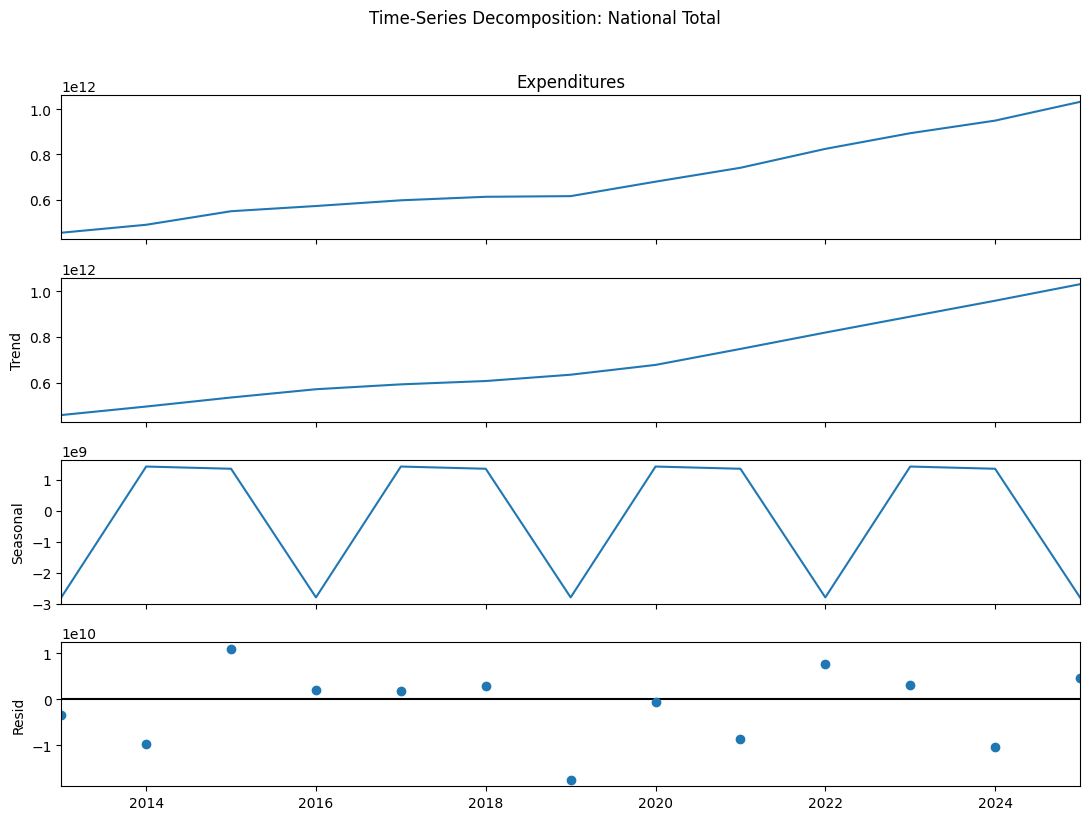

In [11]:
def plot_decomposition(df, title, filename, period=3):
    series = df.sort_values("Fiscal Year").set_index("Fiscal Year")["Expenditures"]
    if len(series) < period * 2:
        print(f"Not enough data for decomposition: {title}")
        return None
    
    decomposition = seasonal_decompose(series, model="additive", period=period, extrapolate_trend="freq")
    fig = decomposition.plot()
    fig.set_size_inches(11, 8)
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    path = CHART_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path

state_decomp_chart = plot_decomposition(state_df, f"Time-Series Decomposition: {STATE.upper()}", "state_decomposition.png")
national_decomp_chart = plot_decomposition(national_df, "Time-Series Decomposition: National Total", "national_decomposition.png")

## 7. Modeling helper functions

We evaluate several forecasting models on the last 3 historical years:

1. Linear Regression
2. Polynomial Regression
3. Exponential Smoothing
4. ARIMA

Metrics used:

- **MAE:** Mean Absolute Error
- **RMSE:** Root Mean Squared Error
- **MAPE:** Mean Absolute Percentage Error

In [12]:
def calculate_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5
    nonzero = actual != 0
    mape = np.mean(np.abs((actual[nonzero] - predicted[nonzero]) / actual[nonzero])) * 100
    return mae, rmse, mape


def evaluate_models(df, entity_name, test_size=3):
    series_df = df.sort_values("Fiscal Year").dropna(subset=["Expenditures"]).copy()
    if len(series_df) <= test_size + 2:
        raise ValueError(f"Not enough observations to evaluate models for {entity_name}.")
    
    train = series_df.iloc[:-test_size].copy()
    test = series_df.iloc[-test_size:].copy()
    
    X_train = train[["Fiscal Year"]]
    y_train = train["Expenditures"]
    X_test = test[["Fiscal Year"]]
    y_test = test["Expenditures"]
    
    results = []
    predictions_by_model = {}
    model_info = {}
    
    # 1. Linear Regression
    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    pred = linear_model.predict(X_test)
    mae, rmse, mape = calculate_metrics(y_test, pred)
    results.append({"Entity": entity_name, "Model": "Linear Regression", "MAE": mae, "RMSE": rmse, "MAPE": mape})
    predictions_by_model["Linear Regression"] = pred
    model_info["Linear Regression"] = {"model": linear_model}
    
    # 2. Polynomial Regression Degree 2
    poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    poly_model.fit(X_train, y_train)
    pred = poly_model.predict(X_test)
    mae, rmse, mape = calculate_metrics(y_test, pred)
    results.append({"Entity": entity_name, "Model": "Polynomial Regression", "MAE": mae, "RMSE": rmse, "MAPE": mape})
    predictions_by_model["Polynomial Regression"] = pred
    model_info["Polynomial Regression"] = {"model": poly_model}
    
    # 3. Exponential Smoothing
    try:
        ets_model = ExponentialSmoothing(y_train.values, trend="add", seasonal=None, initialization_method="estimated")
        ets_fit = ets_model.fit(optimized=True)
        pred = ets_fit.forecast(len(test))
        mae, rmse, mape = calculate_metrics(y_test, pred)
        results.append({"Entity": entity_name, "Model": "Exponential Smoothing", "MAE": mae, "RMSE": rmse, "MAPE": mape})
        predictions_by_model["Exponential Smoothing"] = pred
        model_info["Exponential Smoothing"] = {"model": ets_fit}
    except Exception as e:
        print(f"Exponential Smoothing failed for {entity_name}: {e}")
    
    # 4. ARIMA candidates
    arima_orders = [(1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 0), (0, 2, 1)]
    best_arima = None
    for order in arima_orders:
        try:
            arima_fit = ARIMA(y_train.values, order=order).fit()
            pred = arima_fit.forecast(steps=len(test))
            mae, rmse, mape = calculate_metrics(y_test, pred)
            row = {"Entity": entity_name, "Model": f"ARIMA{order}", "MAE": mae, "RMSE": rmse, "MAPE": mape}
            if best_arima is None or row["MAPE"] < best_arima["MAPE"]:
                best_arima = {**row, "order": order, "fit": arima_fit, "pred": pred}
        except Exception:
            pass
    
    if best_arima is not None:
        results.append({k: best_arima[k] for k in ["Entity", "Model", "MAE", "RMSE", "MAPE"]})
        predictions_by_model[best_arima["Model"]] = best_arima["pred"]
        model_info[best_arima["Model"]] = {"order": best_arima["order"], "model": best_arima["fit"]}
    
    comparison = pd.DataFrame(results).sort_values("MAPE").reset_index(drop=True)
    best_model_name = comparison.loc[0, "Model"]
    
    return comparison, best_model_name, train, test, predictions_by_model, model_info

## 8. Evaluate models for the selected state

In [13]:
state_comparison, state_best_model, state_train, state_test, state_test_predictions, state_model_info = evaluate_models(
    state_df, STATE.upper(), TEST_SIZE
)

print("Best state model:", state_best_model)
display(state_comparison)

Best state model: ARIMA(0, 2, 1)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Entity,Model,MAE,RMSE,MAPE
0,NEW YORK,"ARIMA(0, 2, 1)","5,808,949,818.36","5,871,513,797.11",5.93
1,NEW YORK,Linear Regression,"13,620,957,151.70","13,667,389,832.96",13.81
2,NEW YORK,Exponential Smoothing,"13,620,957,154.88","13,667,389,836.14",13.81
3,NEW YORK,Polynomial Regression,"19,167,953,616.67","19,373,935,440.40",19.39


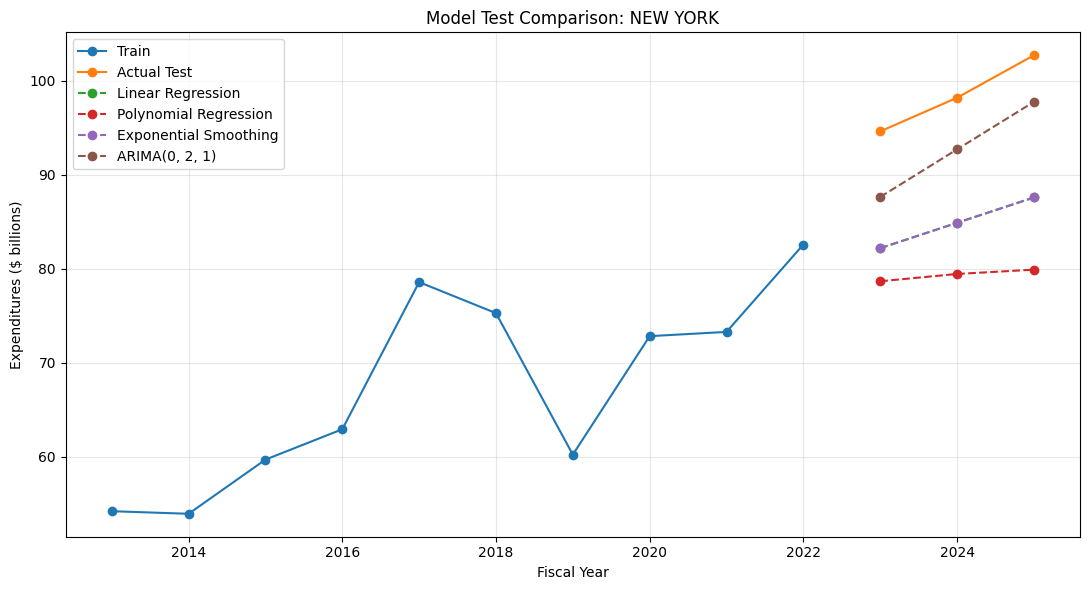

In [14]:
def plot_test_predictions(train, test, predictions_by_model, title, filename):
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(train["Fiscal Year"], dollars_billions(train["Expenditures"]), marker="o", label="Train")
    ax.plot(test["Fiscal Year"], dollars_billions(test["Expenditures"]), marker="o", label="Actual Test")
    
    for model_name, preds in predictions_by_model.items():
        ax.plot(test["Fiscal Year"], dollars_billions(np.asarray(preds)), marker="o", linestyle="--", label=model_name)
    
    ax.set_title(title)
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel("Expenditures ($ billions)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    path = CHART_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path

state_test_chart = plot_test_predictions(
    state_train, state_test, state_test_predictions,
    f"Model Test Comparison: {STATE.upper()}",
    "state_model_test_comparison.png"
)

## 9. Evaluate models for the national total

In [15]:
national_comparison, national_best_model, national_train, national_test, national_test_predictions, national_model_info = evaluate_models(
    national_df, "NATIONAL TOTAL", TEST_SIZE
)

print("Best national model:", national_best_model)
display(national_comparison)

Best national model: Exponential Smoothing


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Entity,Model,MAE,RMSE,MAPE
0,NATIONAL TOTAL,Exponential Smoothing,"26,688,505,644.63","29,144,349,672.47",2.74
1,NATIONAL TOTAL,"ARIMA(0, 2, 1)","30,389,179,093.42","32,801,601,322.81",3.12
2,NATIONAL TOTAL,Polynomial Regression,"47,102,709,309.24","47,978,768,871.70",4.89
3,NATIONAL TOTAL,Linear Regression,"112,706,434,239.57","116,157,169,999.72",11.64


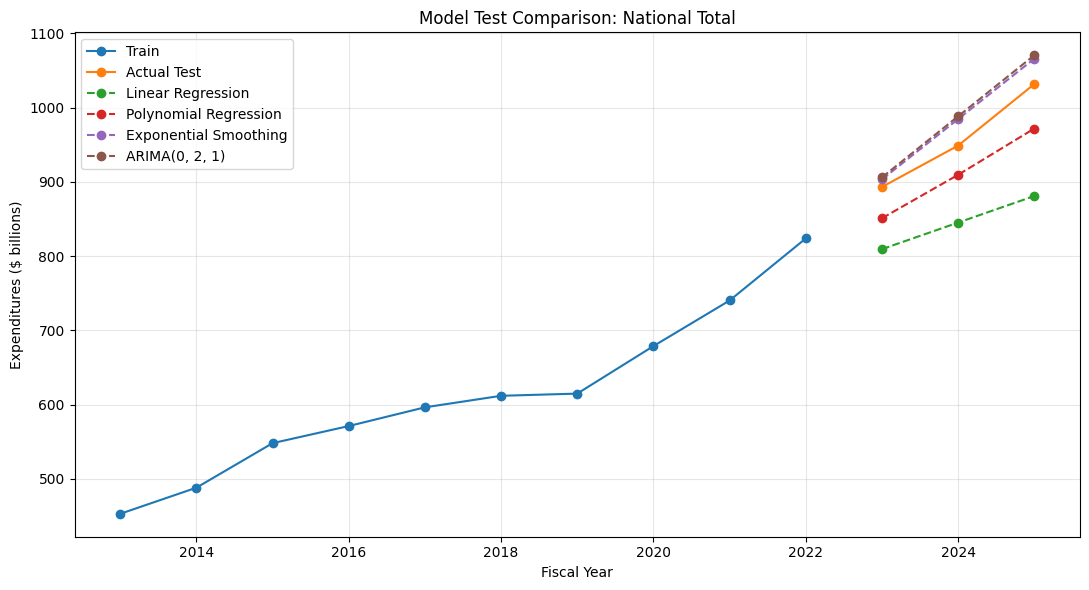

In [16]:
national_test_chart = plot_test_predictions(
    national_train, national_test, national_test_predictions,
    "Model Test Comparison: National Total",
    "national_model_test_comparison.png"
)

## 10. Final forecast functions

The best model by MAPE is refit on all available historical data. The notebook then forecasts 2026-2035 and adds approximate 95% confidence intervals.

For regression and exponential smoothing models, confidence intervals use historical residual variation. For ARIMA models, confidence intervals come from the ARIMA forecast object when available.

In [17]:
def forecast_with_best_model(df, entity_name, best_model_name, forecast_start=2026, forecast_end=2035):
    full = df.sort_values("Fiscal Year").dropna(subset=["Expenditures"]).copy()
    future_years = pd.DataFrame({"Fiscal Year": range(forecast_start, forecast_end + 1)})
    y = full["Expenditures"].astype(float).values
    X = full[["Fiscal Year"]]
    
    lower = None
    upper = None
    order_used = None
    
    if best_model_name == "Linear Regression":
        model = LinearRegression().fit(X, y)
        forecast = model.predict(future_years)
        fitted = model.predict(X)
        resid_std = np.std(y - fitted, ddof=1)
        margin = 1.96 * resid_std
        lower = forecast - margin
        upper = forecast + margin
        method_note = "95% CI approximated using residual standard deviation."
        
    elif best_model_name == "Polynomial Regression":
        model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression()).fit(X, y)
        forecast = model.predict(future_years)
        fitted = model.predict(X)
        resid_std = np.std(y - fitted, ddof=1)
        margin = 1.96 * resid_std
        lower = forecast - margin
        upper = forecast + margin
        method_note = "95% CI approximated using residual standard deviation."
        
    elif best_model_name == "Exponential Smoothing":
        model = ExponentialSmoothing(y, trend="add", seasonal=None, initialization_method="estimated").fit(optimized=True)
        forecast = model.forecast(len(future_years))
        fitted = model.fittedvalues
        resid_std = np.std(y - fitted, ddof=1)
        margin = 1.96 * resid_std
        lower = forecast - margin
        upper = forecast + margin
        method_note = "95% CI approximated using residual standard deviation."
        
    elif best_model_name.startswith("ARIMA"):
        order_match = re.search(r"ARIMA\((\d+),\s*(\d+),\s*(\d+)\)", best_model_name)
        if order_match:
            order_used = tuple(int(x) for x in order_match.groups())
        else:
            order_used = (1, 1, 0)
        model = ARIMA(y, order=order_used).fit()
        forecast_result = model.get_forecast(steps=len(future_years))
        forecast = forecast_result.predicted_mean
        conf = forecast_result.conf_int(alpha=0.05)
        lower = conf[:, 0]
        upper = conf[:, 1]
        method_note = "95% CI generated from ARIMA forecast interval."
        
    else:
        raise ValueError(f"Unsupported model: {best_model_name}")
    
    forecast = np.asarray(forecast, dtype=float)
    lower = np.maximum(np.asarray(lower, dtype=float), 0)
    upper = np.maximum(np.asarray(upper, dtype=float), 0)
    
    forecast_table = pd.DataFrame({
        "Entity": entity_name,
        "Fiscal Year": future_years["Fiscal Year"],
        "Best Model": best_model_name,
        "Projected Expenditures": forecast,
        "Lower 95% CI": lower,
        "Upper 95% CI": upper,
        "CI Method Note": method_note
    })
    
    return forecast_table

state_forecast = forecast_with_best_model(state_df, STATE.upper(), state_best_model, FORECAST_START_YEAR, FORECAST_END_YEAR)
national_forecast = forecast_with_best_model(national_df, "NATIONAL TOTAL", national_best_model, FORECAST_START_YEAR, FORECAST_END_YEAR)

all_forecasts = pd.concat([state_forecast, national_forecast], ignore_index=True)

display(all_forecasts)

,Entity,Fiscal Year,Best Model,Projected Expenditures,Lower 95% CI,Upper 95% CI,CI Method Note
0,NEW YORK,2026,"ARIMA(0, 2, 1)","108,201,664,839.93","85,553,246,869.95","130,850,082,809.90",95% CI generated from ARIMA forecast interval.
1,NEW YORK,2027,"ARIMA(0, 2, 1)","113,704,002,044.85","75,052,687,821.85","152,355,316,267.85",95% CI generated from ARIMA forecast interval.
2,NEW YORK,2028,"ARIMA(0, 2, 1)","119,206,339,249.78","63,588,634,012.61","174,824,044,486.94",95% CI generated from ARIMA forecast interval.
3,NEW YORK,2029,"ARIMA(0, 2, 1)","124,708,676,454.70","50,806,204,624.75","198,611,148,284.65",95% CI generated from ARIMA forecast interval.
4,NEW YORK,2030,"ARIMA(0, 2, 1)","130,211,013,659.63","36,674,539,045.02","223,747,488,274.23",95% CI generated from ARIMA forecast interval.
5,NEW YORK,2031,"ARIMA(0, 2, 1)","135,713,350,864.55","21,230,912,341.91","250,195,789,387.19",95% CI generated from ARIMA forecast interval.
6,NEW YORK,2032,"ARIMA(0, 2, 1)","141,215,688,069.48","4,528,253,918.26","277,903,122,220.69",95% CI generated from ARIMA forecast interval.
7,NEW YORK,2033,"ARIMA(0, 2, 1)","146,718,025,274.40",0.00,"306,815,368,255.37",95% CI generated from ARIMA forecast interval.
8,NEW YORK,2034,"ARIMA(0, 2, 1)","152,220,362,479.33",0.00,"336,881,543,636.18",95% CI generated from ARIMA forecast interval.
9,NEW YORK,2035,"ARIMA(0, 2, 1)","157,722,699,684.25",0.00,"368,054,917,418.15",95% CI generated from ARIMA forecast interval.


## 11. Visualize final forecasts with confidence intervals

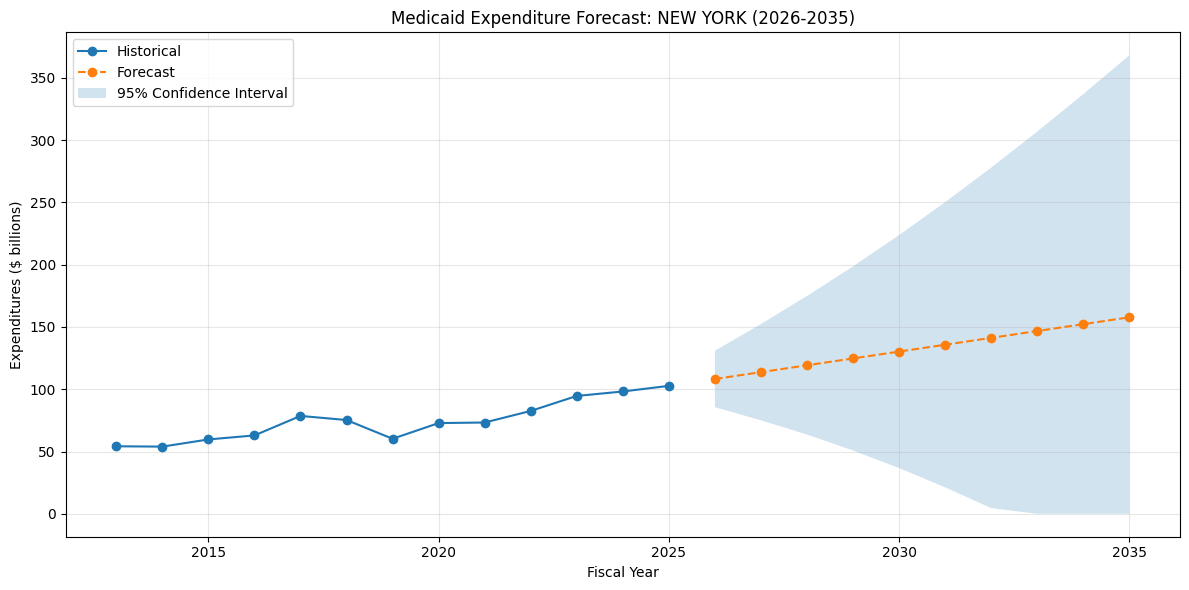

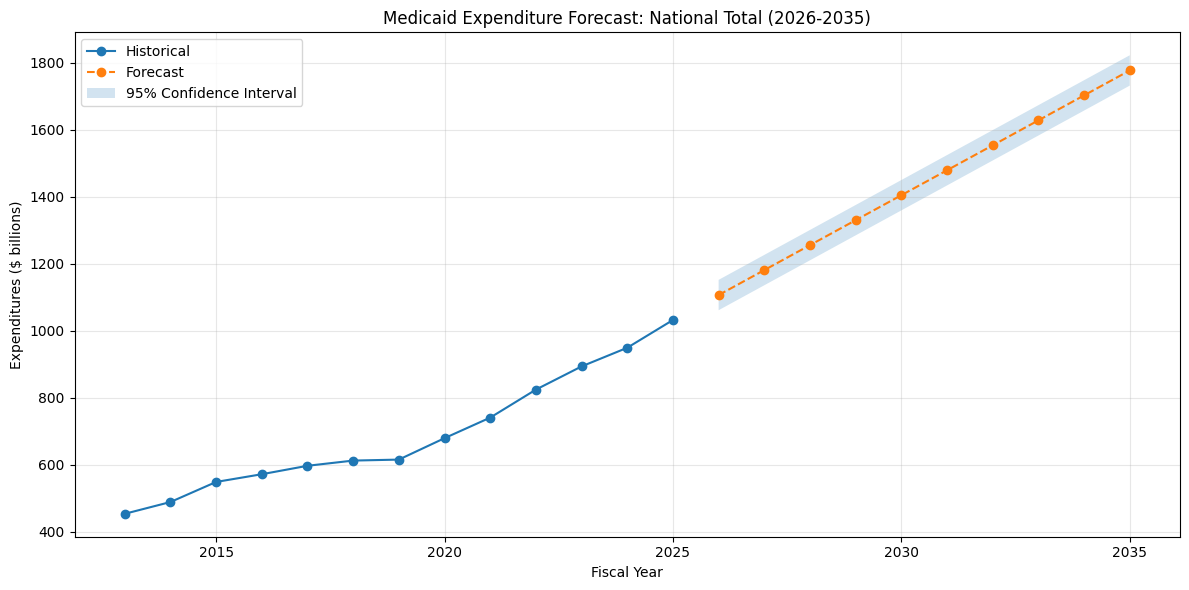

In [18]:
def plot_final_forecast(history_df, forecast_df, title, filename):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    hist = history_df.sort_values("Fiscal Year")
    fc = forecast_df.sort_values("Fiscal Year")
    
    ax.plot(hist["Fiscal Year"], dollars_billions(hist["Expenditures"]), marker="o", label="Historical")
    ax.plot(fc["Fiscal Year"], dollars_billions(fc["Projected Expenditures"]), marker="o", linestyle="--", label="Forecast")
    ax.fill_between(
        fc["Fiscal Year"].astype(float).values,
        dollars_billions(fc["Lower 95% CI"]).astype(float).values,
        dollars_billions(fc["Upper 95% CI"]).astype(float).values,
        alpha=0.2,
        label="95% Confidence Interval"
    )
    
    ax.set_title(title)
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel("Expenditures ($ billions)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    path = CHART_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path

state_forecast_chart = plot_final_forecast(
    state_df, state_forecast,
    f"Medicaid Expenditure Forecast: {STATE.upper()} ({FORECAST_START_YEAR}-{FORECAST_END_YEAR})",
    "state_final_forecast.png"
)

national_forecast_chart = plot_final_forecast(
    national_df, national_forecast,
    f"Medicaid Expenditure Forecast: National Total ({FORECAST_START_YEAR}-{FORECAST_END_YEAR})",
    "national_final_forecast.png"
)

## 12. Model comparison summary

The lowest MAPE model is selected as the final model for each forecast series.

In [19]:
model_comparison = pd.concat([state_comparison, national_comparison], ignore_index=True)
model_comparison = model_comparison.sort_values(["Entity", "MAPE"]).reset_index(drop=True)

display(model_comparison)

best_models_summary = model_comparison.loc[model_comparison.groupby("Entity")["MAPE"].idxmin()].reset_index(drop=True)
display(best_models_summary)

,Entity,Model,MAE,RMSE,MAPE
0,NATIONAL TOTAL,Exponential Smoothing,"26,688,505,644.63","29,144,349,672.47",2.74
1,NATIONAL TOTAL,"ARIMA(0, 2, 1)","30,389,179,093.42","32,801,601,322.81",3.12
2,NATIONAL TOTAL,Polynomial Regression,"47,102,709,309.24","47,978,768,871.70",4.89
3,NATIONAL TOTAL,Linear Regression,"112,706,434,239.57","116,157,169,999.72",11.64
4,NEW YORK,"ARIMA(0, 2, 1)","5,808,949,818.36","5,871,513,797.11",5.93
5,NEW YORK,Linear Regression,"13,620,957,151.70","13,667,389,832.96",13.81
6,NEW YORK,Exponential Smoothing,"13,620,957,154.88","13,667,389,836.14",13.81
7,NEW YORK,Polynomial Regression,"19,167,953,616.67","19,373,935,440.40",19.39


,Entity,Model,MAE,RMSE,MAPE
0,NATIONAL TOTAL,Exponential Smoothing,"26,688,505,644.63","29,144,349,672.47",2.74
1,NEW YORK,"ARIMA(0, 2, 1)","5,808,949,818.36","5,871,513,797.11",5.93


## 13. Export clean forecast tables and reports

This cell exports all main deliverables into Kaggle's `/kaggle/working` folder.

In [20]:
def add_formatted_dollars(df, cols):
    out = df.copy()
    for col in cols:
        out[col + " Formatted"] = out[col].apply(lambda x: f"${x:,.0f}")
    return out

all_forecasts_export = add_formatted_dollars(
    all_forecasts,
    ["Projected Expenditures", "Lower 95% CI", "Upper 95% CI"]
)

state_forecast_export = all_forecasts_export[all_forecasts_export["Entity"] == STATE.upper()].copy()
national_forecast_export = all_forecasts_export[all_forecasts_export["Entity"] == "NATIONAL TOTAL"].copy()

state_forecast_export.to_csv(OUTPUT_DIR / "state_forecast_2026_2035.csv", index=False)
national_forecast_export.to_csv(OUTPUT_DIR / "national_forecast_2026_2035.csv", index=False)
model_comparison.to_csv(OUTPUT_DIR / "model_comparison_summary.csv", index=False)

with pd.ExcelWriter(OUTPUT_DIR / "medicaid_projection_results.xlsx", engine="openpyxl") as writer:
    state_forecast_export.to_excel(writer, sheet_name="State Forecast", index=False)
    national_forecast_export.to_excel(writer, sheet_name="National Forecast", index=False)
    model_comparison.to_excel(writer, sheet_name="Model Comparison", index=False)
    state_eda.to_excel(writer, sheet_name="State EDA", index=False)
    national_eda.to_excel(writer, sheet_name="National EDA", index=False)

print("Exported CSV and Excel files to:", OUTPUT_DIR)

Exported CSV and Excel files to: /kaggle/working


## 14. Create HTML report

In [21]:
html_path = OUTPUT_DIR / "medicaid_projection_report.html"

html = f"""
<html>
<head>
    <title>Medicaid Expenditure Projection Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 40px; line-height: 1.5; }}
        h1, h2 {{ color: #1f4e79; }}
        table {{ border-collapse: collapse; width: 100%; margin-bottom: 24px; }}
        th, td {{ border: 1px solid #ddd; padding: 8px; text-align: right; }}
        th {{ background-color: #f2f2f2; }}
        td:first-child, th:first-child {{ text-align: left; }}
        img {{ max-width: 100%; height: auto; margin: 12px 0 28px 0; }}
    </style>
</head>
<body>
    <h1>Medicaid Expenditure Projection Model</h1>
    <p>This report forecasts Medicaid expenditures for <strong>{STATE.upper()}</strong> and the <strong>national total</strong> for fiscal years {FORECAST_START_YEAR}-{FORECAST_END_YEAR}.</p>
    
    <h2>Best Models</h2>
    {best_models_summary.to_html(index=False)}
    
    <h2>Model Comparison</h2>
    {model_comparison.to_html(index=False)}
    
    <h2>Forecast Table</h2>
    {all_forecasts_export[["Entity", "Fiscal Year", "Best Model", "Projected Expenditures Formatted", "Lower 95% CI Formatted", "Upper 95% CI Formatted"]].to_html(index=False)}
    
    <h2>Charts</h2>
    <h3>{STATE.upper()} Forecast</h3>
    <img src="charts/state_final_forecast.png">
    <h3>National Forecast</h3>
    <img src="charts/national_final_forecast.png">
</body>
</html>
"""

html_path.write_text(html, encoding="utf-8")
print("HTML report saved to:", html_path)

HTML report saved to: /kaggle/working/medicaid_projection_report.html


## 15. Create PDF report

This creates a simple PDF report containing the main charts and summary tables.

In [22]:
pdf_path = OUTPUT_DIR / "medicaid_projection_report.pdf"

with PdfPages(pdf_path) as pdf:
    # Title page
    fig, ax = plt.subplots(figsize=(11, 8.5))
    ax.axis("off")
    title_text = f"""
    Medicaid Expenditure Projection Model

    Selected State: {STATE.upper()}
    National Total Included: Yes
    Forecast Period: {FORECAST_START_YEAR}-{FORECAST_END_YEAR}

    Models Compared:
    - Linear Regression
    - Polynomial Regression
    - Exponential Smoothing
    - ARIMA

    Evaluation Metrics:
    - MAE
    - RMSE
    - MAPE
    """
    ax.text(0.05, 0.95, title_text, va="top", fontsize=14)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)
    
    # Forecast charts
    for image_path in [state_forecast_chart, national_forecast_chart, state_growth_chart, national_growth_chart]:
        if image_path is not None and Path(image_path).exists():
            img = plt.imread(image_path)
            fig, ax = plt.subplots(figsize=(11, 8.5))
            ax.imshow(img)
            ax.axis("off")
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)
    
    # Model comparison table page
    fig, ax = plt.subplots(figsize=(11, 8.5))
    ax.axis("off")
    table_text = model_comparison.round(2).to_string(index=False)
    ax.text(0.02, 0.98, "Model Comparison Summary\n\n" + table_text, va="top", family="monospace", fontsize=8)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)
    
    # Forecast table page
    fig, ax = plt.subplots(figsize=(11, 8.5))
    ax.axis("off")
    forecast_cols = ["Entity", "Fiscal Year", "Best Model", "Projected Expenditures Formatted", "Lower 95% CI Formatted", "Upper 95% CI Formatted"]
    forecast_text = all_forecasts_export[forecast_cols].to_string(index=False)
    ax.text(0.02, 0.98, "Forecast Table\n\n" + forecast_text, va="top", family="monospace", fontsize=7)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print("PDF report saved to:", pdf_path)

PDF report saved to: /kaggle/working/medicaid_projection_report.pdf


## 16. Create README file

The assignment asks for setup instructions and usage guidance. This cell writes a README file automatically.

In [23]:
readme_text = f"""
# Medicaid Expenditure Projection Model

## Overview
This project analyzes historical Medicaid expenditure data and forecasts expenditures for {STATE.upper()} and the national total for fiscal years {FORECAST_START_YEAR}-{FORECAST_END_YEAR}.

## Tools Used
- Python
- pandas
- numpy
- matplotlib
- scikit-learn
- statsmodels
- openpyxl

## Data
The input data consists of FY 2013-FY 2025 MFCU Statistical Chart Excel files.

## Methodology
1. Load all Excel files.
2. Clean state names and Medicaid expenditure fields.
3. Perform exploratory data analysis, including historical trends and year-over-year growth.
4. Decompose the time series into trend, seasonal-like, and residual components.
5. Train and evaluate multiple models:
   - Linear Regression
   - Polynomial Regression
   - Exponential Smoothing
   - ARIMA
6. Compare models using MAE, RMSE, and MAPE.
7. Select the best-performing model for each series.
8. Forecast Medicaid expenditures for {FORECAST_START_YEAR}-{FORECAST_END_YEAR} with 95% confidence intervals.
9. Export results to CSV, Excel, HTML, and PDF.

## Main Outputs
- state_forecast_2026_2035.csv
- national_forecast_2026_2035.csv
- model_comparison_summary.csv
- medicaid_projection_results.xlsx
- medicaid_projection_report.html
- medicaid_projection_report.pdf
- charts/ folder with visualization outputs

## How to Run on Kaggle
1. Open this notebook in Kaggle.
2. Upload or attach the dataset containing the FY Excel files.
3. Set the `STATE` variable near the top of the notebook.
4. Run all cells from top to bottom.
5. Download the output files from `/kaggle/working`.

## Notes
Confidence intervals for regression and exponential smoothing models are approximate and based on residual error. ARIMA confidence intervals are generated from the model forecast distribution when ARIMA is selected as the best model.
"""

readme_path = OUTPUT_DIR / "README.md"
readme_path.write_text(readme_text.strip(), encoding="utf-8")
print("README saved to:", readme_path)

README saved to: /kaggle/working/README.md


## 17. Final output file list

Run this final cell to confirm all exportable deliverables were created.

In [24]:
print("Exported files:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(path)

Exported files:
/kaggle/working/README.md
/kaggle/working/__notebook__.ipynb
/kaggle/working/charts/national_decomposition.png
/kaggle/working/charts/national_final_forecast.png
/kaggle/working/charts/national_historical_expenditures.png
/kaggle/working/charts/national_model_test_comparison.png
/kaggle/working/charts/national_yoy_growth.png
/kaggle/working/charts/state_decomposition.png
/kaggle/working/charts/state_final_forecast.png
/kaggle/working/charts/state_historical_expenditures.png
/kaggle/working/charts/state_model_test_comparison.png
/kaggle/working/charts/state_yoy_growth.png
/kaggle/working/medicaid_projection_report.html
/kaggle/working/medicaid_projection_report.pdf
/kaggle/working/medicaid_projection_results.xlsx
/kaggle/working/model_comparison_summary.csv
/kaggle/working/national_forecast_2026_2035.csv
/kaggle/working/state_forecast_2026_2035.csv


# Conclusion

This notebook completes the Medicaid Expenditure Projection Model workflow by producing forecasts for the selected state and the national total, comparing multiple models, adding confidence intervals, and exporting the final deliverables.